In [1]:
# CELL 1: Setup
import os
import sys
sys.path.append('..')

import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_patient_splits
from models.bu_net import BUNet
from data.few_shot_sampler import FewShotSampler, kshot_finetune_eval
from configs.results_utils import save_kshot_results, print_kshot_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Load Pretrained Baseline
model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

load_model_weights(model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)

✓ Loaded checkpoint: best_model.pth


True

In [3]:
# CELL 3: Build Few-Shot Samplers
train_ids, val_ids, test_ids = get_patient_splits(Config.TRAIN_DATASET_PATH)

# Use val patients as support, test patients as query
# This avoids any data leakage from training
samplers = {}
for k in Config.K_SHOT_VALUES:
    samplers[k] = FewShotSampler(
        support_ids=val_ids,
        query_ids=test_ids,
        data_path=Config.TRAIN_DATASET_PATH,
        k_shot=k,
        n_query=Config.N_QUERY,
        tumor_only=True,
    )
    print(f"✓ Built sampler for k={k}")

✓ Splits -> Train: 258, Val: 74, Test: 37
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=1
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=5
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=10
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Built sampler for k=20


In [4]:
# CELL 4: Run k-Shot Evaluation
results = {}

for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"Evaluating k={k} shot (50 episodes)...")
    print(f"{'='*50}")

    dice_scores = kshot_finetune_eval(
        pretrained_model=model,
        sampler=samplers[k],
        device=Config.DEVICE,
        lr=1e-4,
        finetune_steps=10,
        n_episodes=50,
    )

    results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
        'scores': [float(d) for d in dice_scores],
    }

print_kshot_results(results, Config.K_SHOT_VALUES, "BASELINE K-SHOT RESULTS")
save_kshot_results(results, Config.RESULTS_DIR, 'baseline_kshot_results.json')


Evaluating k=1 shot (50 episodes)...
  Episode 10/50 | Mean Dice: 0.5853
  Episode 20/50 | Mean Dice: 0.6096
  Episode 30/50 | Mean Dice: 0.6094
  Episode 40/50 | Mean Dice: 0.5970
  Episode 50/50 | Mean Dice: 0.5947

k=1 shot | Mean Dice over 50 episodes: 0.5947 ± 0.1375

Evaluating k=5 shot (50 episodes)...
  Episode 10/50 | Mean Dice: 0.7007
  Episode 20/50 | Mean Dice: 0.7136
  Episode 30/50 | Mean Dice: 0.7321
  Episode 40/50 | Mean Dice: 0.7321
  Episode 50/50 | Mean Dice: 0.7320

k=5 shot | Mean Dice over 50 episodes: 0.7320 ± 0.0831

Evaluating k=10 shot (50 episodes)...
  Episode 10/50 | Mean Dice: 0.7085
  Episode 20/50 | Mean Dice: 0.7328
  Episode 30/50 | Mean Dice: 0.7319
  Episode 40/50 | Mean Dice: 0.7318
  Episode 50/50 | Mean Dice: 0.7361

k=10 shot | Mean Dice over 50 episodes: 0.7361 ± 0.0778

Evaluating k=20 shot (50 episodes)...
  Episode 10/50 | Mean Dice: 0.7290
  Episode 20/50 | Mean Dice: 0.7298
  Episode 30/50 | Mean Dice: 0.7261
  Episode 40/50 | Mean Dice: 

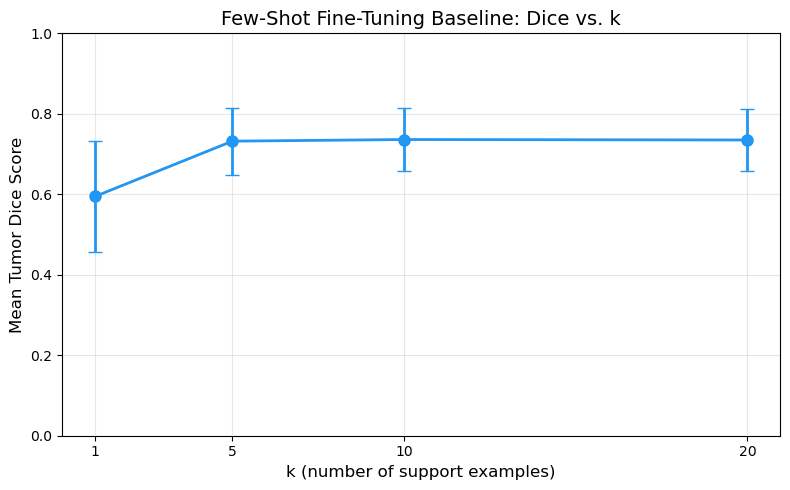

In [5]:
# CELL 5: K-Shot Learning Curve
k_values = Config.K_SHOT_VALUES
means = [results[k]['mean'] for k in k_values]
stds = [results[k]['std'] for k in k_values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(k_values, means, yerr=stds, marker='o', capsize=5,
            linewidth=2, markersize=8, color='#2196F3')
ax.set_xlabel('k (number of support examples)', fontsize=12)
ax.set_ylabel('Mean Tumor Dice Score', fontsize=12)
ax.set_title('Few-Shot Fine-Tuning Baseline: Dice vs. k', fontsize=14)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'baseline_kshot_curve.png'), dpi=150)
plt.show()